# Задача классификации

• основе датасета, который был использован вами для промежуточной аттестации (или другого):

• Выберите бинарную переменную (или сконструируйте из количественной)

• Выберите несколько объясняющих переменных

• Разделите датасет на обучающую и тестовую выборки

• Обучите модель KNN на обучающей выборке

• Постройте графики recall-precision и roc

• Выберите и обоснуйте порог предсказания Y = 1

• Сделайте предсказания целевой переменной для тестовой выборки

• Постройте матрицу ошибок

• Рассчитайте метрики качества

• Сделайте выводы относительно полученной модели, ее качества и полученных зависимостей

• Разместите блокнот в GitHub и прикрепите ссылку на блокнот в удаленном репозитории

# Подготовка


## Данные

Данные были сформированы из MSSQL Server базы компании и выгружены в Excel для дальнейшей обработки. В качестве источника представлены два набора данных:
* empl_1.xlsx - список сотрудников по месячно, (date - месяц и год, qnt - количество сотрудников, имеющих доступ к компьютерам, qnt_total - общее количество сотрудников)
* data_1.xlsx - список покупок (я удалил конкретные наименования товаров, оставил только категории( date - месяц и год, category - категория, qnt - количество)

## Описание задачи

В качестве задачи я решил взять предсказание затрат на Мониторы в следующем месяце (взял только одну категорию товаров, для примера).


## Импорт пакетов

In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, roc_curve, average_precision_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
sns.set_theme()

## Загрузка данных

In [123]:
employeeRaw = (pd
                .read_excel("empl_1.xlsx")
                .sort_values('date')
)
dataRaw = (pd
           .read_excel("data_1.xlsx")
           .sort_values('date')
)
print("Сотрудники: ", employeeRaw.shape)
print("Покупки: ", dataRaw.shape)

print(dataRaw.groupby("category").nunique().index.tolist())

Сотрудники:  (129, 3)
Покупки:  (4728, 4)
['Батарейка', 'Блок питания', 'Веб-камера', 'Видеокарта', 'Жесткий диск', 'Запчасти для компьютера', 'Запчасти для принтера', 'Кабель/Адаптер', 'Картридж', 'Клавиатура', 'Коммутатор/Свитч/Роутер', 'Компьютер/Ноутбук', 'Корпус компьютерный', 'МФУ', 'Материнская плата', 'Монитор', 'Мышь', 'Наушники', 'ОЗУ', 'Принтер', 'Программное обеспечение', 'Процессор', 'Прочее', 'Сетевое оборудование', 'Смартфон/Мобильное устройство', 'Телевизор', 'Тонер/Чернила', 'Флеш накопитель']


In [124]:
dataRaw.groupby("category").agg(recCount = ("date", "count")).sort_values("recCount", ascending = False)

,recCount
category,
Запчасти для принтера,982
Картридж,801
Прочее,603
Тонер/Чернила,330
Кабель/Адаптер,303
Жесткий диск,222
Мышь,172
Запчасти для компьютера,158
Компьютер/Ноутбук,143


## Подготавливаем данные

In [125]:
## Сотрудники
employee = (
    employeeRaw
    .assign(delta = lambda x: x["qty"] - x["qty"].shift(1))
    .assign(year = lambda x: x["date"].dt.year)
    .assign(month = lambda x: x["date"].dt.month)
    .assign(quarter = lambda x: x["date"].dt.quarter)
    .fillna(0)
)

print(employee)

          date  total_qty  qty  delta  year  month  quarter
0   2016-01-01        842  484    0.0  2016      1        1
1   2016-02-01        840  483   -1.0  2016      2        1
2   2016-03-01        841  487    4.0  2016      3        1
3   2016-04-01        841  489    2.0  2016      4        2
4   2016-05-01        838  489    0.0  2016      5        2
..         ...        ...  ...    ...   ...    ...      ...
124 2026-05-01        997  577    5.0  2026      5        2
125 2026-06-01        997  576   -1.0  2026      6        2
126 2026-07-01        998  578    2.0  2026      7        3
127 2026-08-01        996  577   -1.0  2026      8        3
128 2026-09-01        996  577    0.0  2026      9        3

[129 rows x 7 columns]


In [126]:
## Покупки
dataMonitor = ((
    dataRaw[dataRaw["category"] == "Монитор"]
    #dataRaw[dataRaw["category"] == "Запчасти для принтера"] # Самая большая выборка
    #dataRaw[dataRaw["category"] == "Картридж"]
    #dataRaw[dataRaw["category"] == "Компьютер/Ноутбук"]
    .groupby("date")
    .agg(
        data_qty = ("qty", "sum"),
        sum = ("sum", "sum")
    )
    .merge(employee, how="right", on="date")
    # заполняем пропуски методом средней интерполяции
    .interpolate(method='linear')
    .assign(
        is_crysis = lambda x: x["year"] >= 2022,
        is_winter = lambda x: x["month"].isin([1, 2, 12]),
        is_spring = lambda x: x["month"].isin([3, 4, 5]),
        is_summer = lambda x: x["month"].isin([6, 7, 8]),
        # количество за прошлый месяц
        qty_lag1 = lambda x: x["qty"].shift(1),
        # сумма за прошлый месяц
        sum_lag1 = lambda x: x["sum"].shift(1),
        # сумма за прошлый месяц
        sum_lag2 = lambda x: x["sum"].shift(2),
        # среднее количество за прошлый месяц
        sum_avg3 = lambda x: x["sum"].rolling(window=3, min_periods=1).mean(),
        # среднее количество за прошлый год
        sum_avg12 = lambda x: x["sum"].rolling(window=12, min_periods=1).mean(),
        # сумма за прошлый месяц
        data_qty_lag1 = lambda x: x["data_qty"].shift(1),
        # сумма за прошлый месяц
        data_qty_lag2 = lambda x: x["data_qty"].shift(2),
        # количество за прошлый месяц
        data_qty_avg3 = lambda x: x["data_qty"].rolling(window=3, min_periods=1).mean(),
        # среднее количество за прошлый год
        data_qty_avg12 = lambda x: x["data_qty"].rolling(window=12, min_periods=1).mean(),
        # дельта покупки
        data_qty_delta =  lambda x: np.where((x["data_qty"] > x["data_qty_lag1"]) & (x["data_qty_lag1"] > 0), 1, 0
    )
    )
    # заполняем пропуски последующие
    .ffill()
    # заполняем пропуски предыдущие
    .bfill()
    # заполняем пустоты
    .fillna(0)
)
    .sort_values("date")
    .reset_index(drop=True)
)
#Суммарное значение
dataMonitor["data_qty_cumsum"] = dataMonitor["data_qty"].cumsum()
# Поиск количества старых мониторов
dates  = pd.to_datetime(dataMonitor["date"])
cumsum = pd.Series(dataMonitor["data_qty"].cumsum().values, index=dates)
cutoff = dates - pd.DateOffset(years=5)
dataMonitor["data_qty_old_by_years"] = (
    cumsum.reindex(cutoff, method="ffill")
          .fillna(0)
          .to_numpy()
)

print(dataMonitor.tail(5))

          date  data_qty        sum  total_qty  qty  delta  year  month  \
124 2026-05-01       6.0   67738.51        997  577    5.0  2026      5   
125 2026-06-01       6.0   74852.46        997  576   -1.0  2026      6   
126 2026-07-01      12.0  141147.60        998  578    2.0  2026      7   
127 2026-08-01      12.0  141147.60        996  577   -1.0  2026      8   
128 2026-09-01      12.0  141147.60        996  577    0.0  2026      9   

     quarter  is_crysis  ...   sum_lag2       sum_avg3      sum_avg12  \
124        2       True  ...   63770.50   63827.053333  109348.876250   
125        2       True  ...   59972.15   67521.040000  110332.761250   
126        3       True  ...   67738.51   94579.523333  117163.808750   
127        3       True  ...   74852.46  119049.220000  114797.635417   
128        3       True  ...  141147.60  141147.600000  113859.240417   

     data_qty_lag1  data_qty_lag2  data_qty_avg3  data_qty_avg12  \
124            6.0            5.0       5.

In [127]:
def split_train_test(df, features_col, target_col):
    X = df[features_col]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
    return X_train, X_test, y_train, y_test

def train_model(X_train, y_train, n_neighbors=3):
    model = KNeighborsClassifier(n_neighbors)
    model.fit(X_train, y_train)
    return model

def get_predictions(model, X_test, proba = False):
    if proba:
        return model.predict_proba(X_test)[:, 1]
    else:
        return model.predict(X_test)

def visualize_prediction(y_true, y_pred, model):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()
    plt.show()

def show_metrics(y_true, y_pred):
    print('Среднее значение Y: ', np.mean(y_true))
    print('Accuracy: ', accuracy_score(y_true, y_pred)),
    print('Precision: ', precision_score(y_true, y_pred))
    print('Recall: ', recall_score(y_true, y_pred))
    print('F1: ', f1_score(y_true, y_pred))
    print('ROC-AUC: ', roc_auc_score(y_true, y_pred))

# Домашнее задание

## 1. Подготовка данных

In [128]:
# Указываем целевую переменную
# Количество мониторов
target_column = 'data_qty_delta'

# Убираем выбросы по правилу +/- 2 стандартных отклонения, z-score'
numeric_cols = ['data_qty_delta', 'data_qty', 'is_crysis', 'is_winter', 'is_spring', 'is_summer', 'data_qty_avg3', 'data_qty_avg12']
df = dataMonitor[numeric_cols]
#df = df[dataMonitor["is_crysis"] == True]
print(df.shape)


(129, 8)


In [129]:
df.head()

,data_qty_delta,data_qty,is_crysis,is_winter,is_spring,is_summer,data_qty_avg3,data_qty_avg12
0,0,1.0,False,True,False,False,1.0,1.0
1,0,1.0,False,True,False,False,1.0,1.0
2,0,1.0,False,False,True,False,1.0,1.0
3,0,1.0,False,False,True,False,1.0,1.0
4,0,1.0,False,False,True,False,1.0,1.0


## 2. Изучаем связь целевой переменной и предикторов

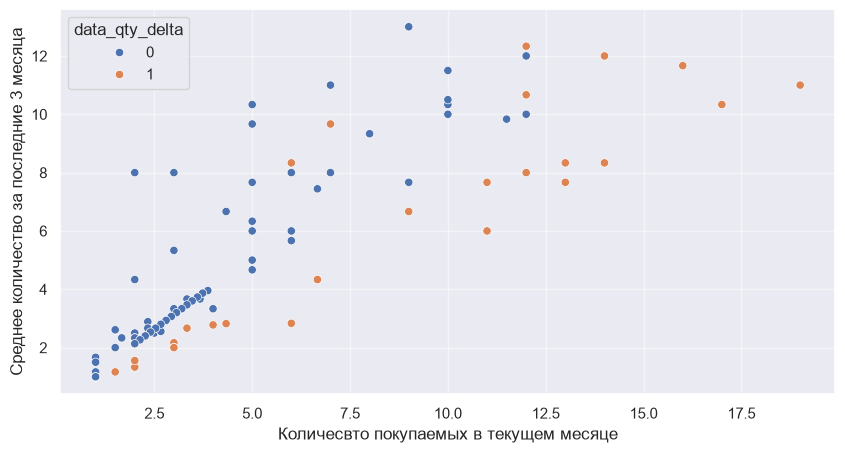

In [130]:
fig, ax = plt.subplots(1,1, figsize = (10, 5))
sns.scatterplot(x = "data_qty", y = "data_qty_avg3", data = df, hue = "data_qty_delta", ax = ax)
ax.set_xlabel("Количесвто покупаемых в текущем месяце")
ax.set_ylabel("Среднее количество за последние 3 месяца")
plt.show()

## Простая модель KNN с двумя предикторами без масштабирования

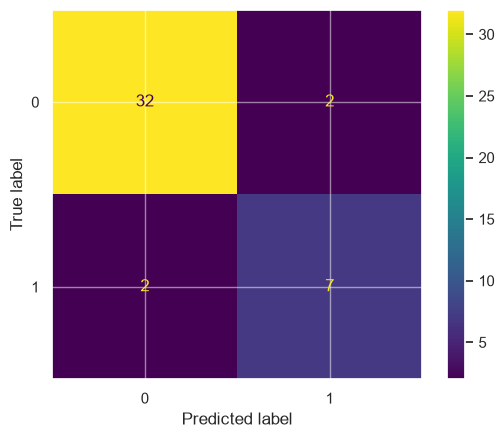

Среднее значение Y:  0.20930232558139536
Accuracy:  0.9069767441860465
Precision:  0.7777777777777778
Recall:  0.7777777777777778
F1:  0.7777777777777778
ROC-AUC:  0.8594771241830065


In [131]:
features_col = ["data_qty", "data_qty_avg3"]
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_column)
model = train_model(X_train, y_train.values.ravel())
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred, model)
show_metrics(y_test, y_pred)

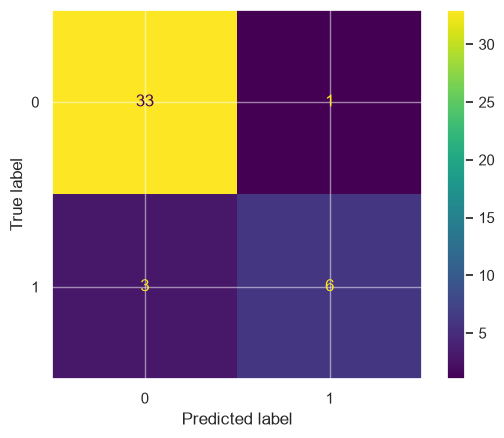

Среднее значение Y:  0.20930232558139536
Accuracy:  0.9069767441860465
Precision:  0.8571428571428571
Recall:  0.6666666666666666
F1:  0.75
ROC-AUC:  0.818627450980392


In [132]:
# С масштабированием
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_column)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = train_model(X_train_scaled, y_train.values.ravel())
y_pred = get_predictions(model, X_test_scaled)
visualize_prediction(y_test, y_pred, model)
show_metrics(y_test, y_pred)

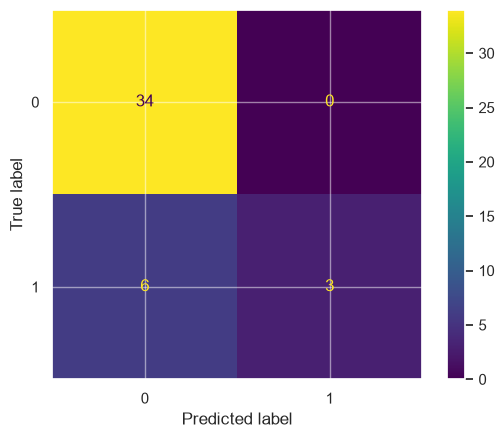

Среднее значение Y:  0.20930232558139536
Accuracy:  0.8604651162790697
Precision:  1.0
Recall:  0.3333333333333333
F1:  0.5
ROC-AUC:  0.6666666666666666


In [133]:
# Простая модель KNN с двумя предикторами c масштабированием и N = 5
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_column)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = train_model(X_train_scaled, y_train.values.ravel(), n_neighbors=5)
y_pred = get_predictions(model, X_test_scaled)
visualize_prediction(y_test, y_pred, model)
show_metrics(y_test, y_pred)

D:\_edu\ai-learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


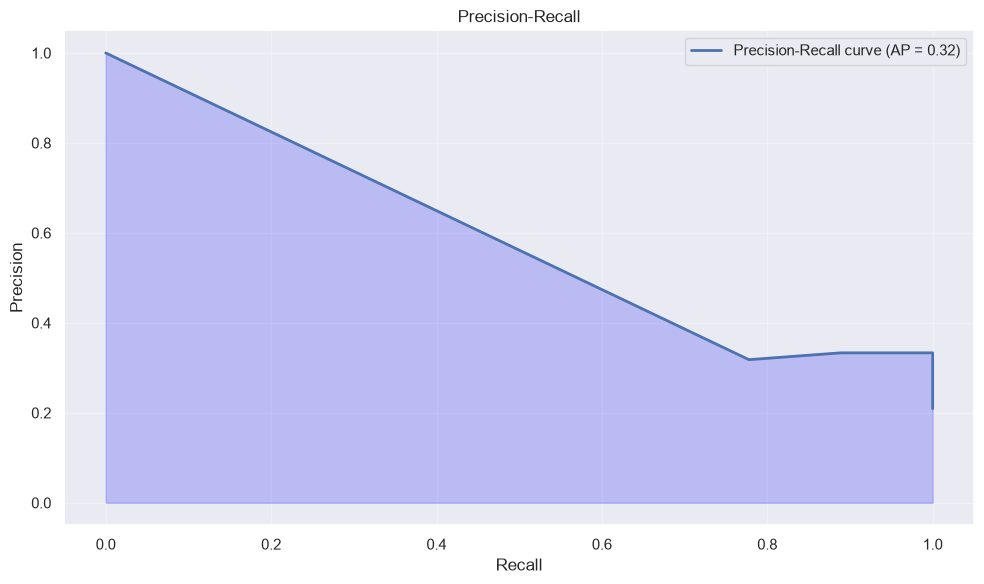

Среднее значение: 0.3215


In [134]:

# Получаем предсказания вероятностей
y_scores = model.predict_proba(X_test)[:, 1]  # вероятности для положительного класса

# График Precision-Recall
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, 'b-', linewidth=2,
         label=f'Precision-Recall curve (AP = {avg_precision:.2f})')
plt.fill_between(recall, precision, alpha=0.2, color='blue')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title("Precision-Recall")
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Среднее значение: {avg_precision:.4f}")

Исходя из результатов видно, что данная модель работает слабо, т.е. примененные признаки скорее всего они сильно коррелируют между собой

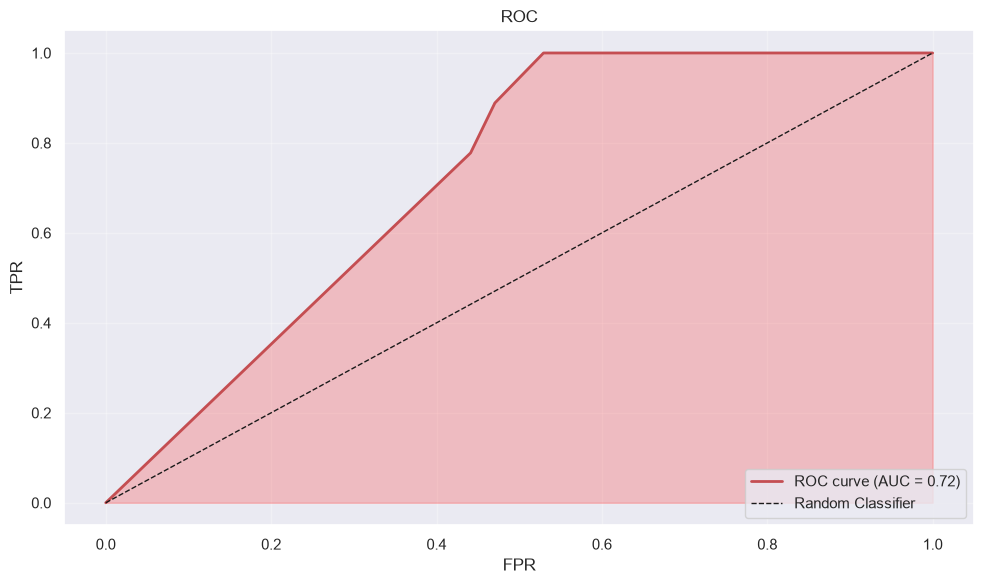

Результат ROC: 0.7222


In [135]:
# График ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, 'r-', linewidth=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.2, color='red')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Результат ROC: {roc_auc:.4f}")

График показывает, что модель предсказывает правильно с вероятностью 72